# Análisis de Mercado Futbolístico
Análisis exploratorio de datos de jugadores y equipos de fútbol
**Autor:** ANGEL ABDEL ROBLES CARREON


In [10]:
#Importacion de librerias.
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
#Carga de datos.
df = pd.read_csv ("DATASET.csv")

In [12]:
#Limpieza de datos
print(df.shape)
print(df.isnull().sum())
df.head()

# ===== VERIFICAR DUPLICADOS =====
print("Filas totalmente duplicadas:", df.duplicated().sum())
df[df.duplicated(keep=False)]

# ===== ELIMINAR DUPLICADOS (solo si el paso anterior mostró duplicados reales) =====
df = df.drop_duplicates()
print("Nueva forma del dataset:", df.shape)


# ===== FUNCIÓN PARA CONVERTIR VALORES MONETARIOS (€, m, bn, k) =====
def convertir_valor(valor):
    if isinstance(valor, (int, float)):
        return valor

    valor = valor.replace("€", "").replace(" ", "")

    if "bn" in valor:
        return float(valor.replace("bn", "")) * 1000  # convertir a millones
    elif "m" in valor:
        return float(valor.replace("m", ""))
    elif "k" in valor:
        return float(valor.replace("k", "")) / 1000  # convertir a millones
    else:
        return float(valor)


# ===== APLICAR LA FUNCIÓN A LAS COLUMNAS DE VALOR DE MERCADO =====
df["Market_value"] = df["Market_value"].apply(convertir_valor)
df["Market_value_of_players"] = df["Market_value_of_players"].apply(convertir_valor)
df["MV_Top_18_players"] = df["MV_Top_18_players"].apply(convertir_valor)

# ===== VERIFICACIÓN FINAL =====
df.info()
df.isnull().sum()
df.head()

(100, 8)
Club                       0
Competition                0
Age                        0
Squad_size                 0
Market_value               0
Market_value_of_players    0
MV_Top_18_players          0
Share_of_MV                0
dtype: int64
Filas totalmente duplicadas: 0
Nueva forma del dataset: (100, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Club                     100 non-null    object 
 1   Competition              100 non-null    object 
 2   Age                      100 non-null    float64
 3   Squad_size               100 non-null    int64  
 4   Market_value             100 non-null    float64
 5   Market_value_of_players  100 non-null    float64
 6   MV_Top_18_players        100 non-null    float64
 7   Share_of_MV              100 non-null    object 
dtypes: float64(4), int64(1), object(3

,Club,Competition,Age,Squad_size,Market_value,Market_value_of_players,MV_Top_18_players,Share_of_MV
0,Manchester City,Premier League,27.2,23,1050.00,45.75,988.0,93.9 %
1,Paris Saint-Germain,Ligue 1,26.1,35,997.75,28.51,889.0,89.1 %
2,Manchester United,Premier League,28.0,28,937.25,33.47,850.0,90.7 %
3,Chelsea FC,Premier League,26.8,27,882.50,32.69,816.0,92.5 %
4,Liverpool FC,Premier League,27.0,27,879.50,32.57,810.5,92.2 %


Competition
Premier League        17.497000
LaLiga                12.842857
Ligue 1               12.468571
Serie A               10.808750
Bundesliga            10.125000
Liga Bwin              8.227500
Eredivisie             7.733333
Premier Liga           5.293333
Jupiler Pro League     5.070000
Championship           4.736667
Série A                4.190000
1.HNL                  3.770000
Premiership            3.620000
Super League 1         3.590000
Liga Profesional       3.580000
Süper Lig              3.540000
Name: Market_value_of_players, dtype: float64


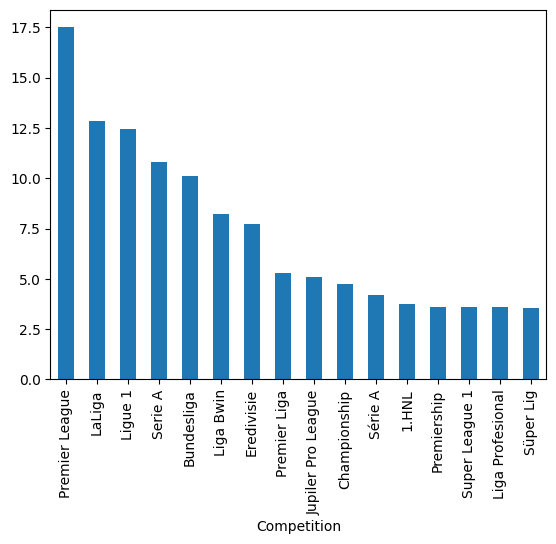

In [13]:
# ¿Qué liga tiene los jugadores con mayor valor promedio?

ligamayorjugadorpromedio = df.groupby("Competition")["Market_value_of_players"]
print(ligamayorjugadorpromedio.mean().sort_values(ascending=False))

ligamayorjugadorpromedio.mean().sort_values(ascending=False).plot(kind = "bar")
plt.show()


## ¿Qué liga tiene los jugadores con mayor valor promedio?
La **Premier League** lidera con el valor de mercado promedio más alto,
seguida de LaLiga y Ligue 1. Esto refleja el poder económico de las
ligas Top 5 europeas frente a competiciones menores.

Competition
1.HNL                 26.200000
Bundesliga            25.078571
Championship          26.800000
Eredivisie            24.700000
Jupiler Pro League    23.700000
LaLiga                27.292857
Liga Bwin             26.300000
Liga Profesional      27.700000
Ligue 1               24.657143
Premier League        26.740000
Premier Liga          26.100000
Premiership           27.500000
Serie A               26.956250
Super League 1        26.100000
Série A               27.100000
Süper Lig             26.600000
Name: Age, dtype: float64


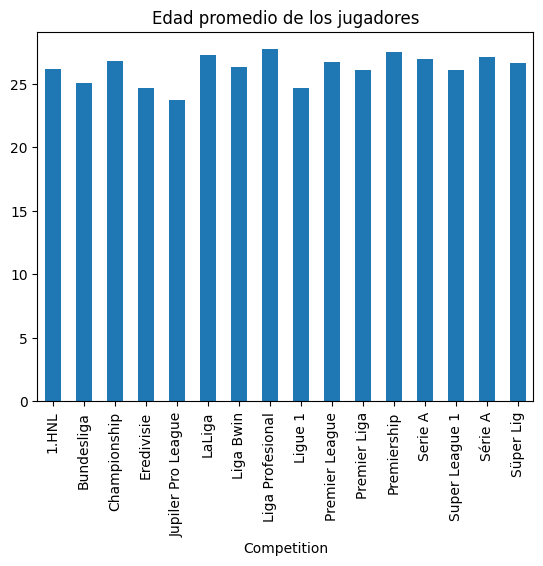

In [35]:
#¿Cuál es la edad promedio de los jugadores?


Promediodeedadjugadores = df.groupby("Competition")["Age"].mean()
print(Promediodeedadjugadores)
Promediodeedadjugadores.plot(kind = "bar")
plt.title("Edad promedio de los jugadores")
plt.show()

## ¿Cuál es la edad promedio de los jugadores?
La edad promedio se concentra entre los 24 y 27 años en la mayoría
de las ligas, lo que representa el pico de rendimiento de un jugador profesional.

Club
Manchester City        1050.00
Paris Saint-Germain     997.75
Manchester United       937.25
Chelsea FC              882.50
Liverpool FC            879.50
Name: Market_value, dtype: float64


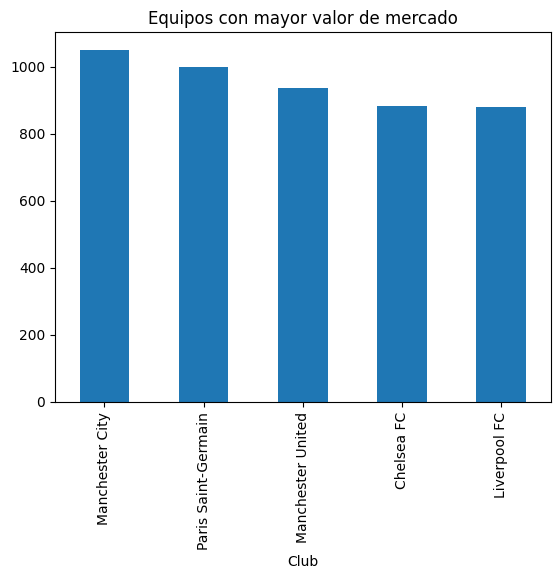

In [36]:
# ¿Qué equipos concentran mayor valor de mercado?

equiposconmayorvalordemercado = df.groupby("Club")["Market_value"].sum().sort_values(ascending=False).head(5)
print(equiposconmayorvalordemercado)

equiposconmayorvalordemercado.plot(kind = "bar")
plt.title("Equipos con mayor valor de mercado")
plt.show()


## ¿Qué equipos concentran mayor valor de mercado?
Los 5 equipos con mayor valor de mercado total pertenecen en su mayoría
a las ligas Top 5 europeas, concentrando una parte significativa
del valor global del mercado futbolístico.

Correlación entre edad y valor de mercado: 0.10


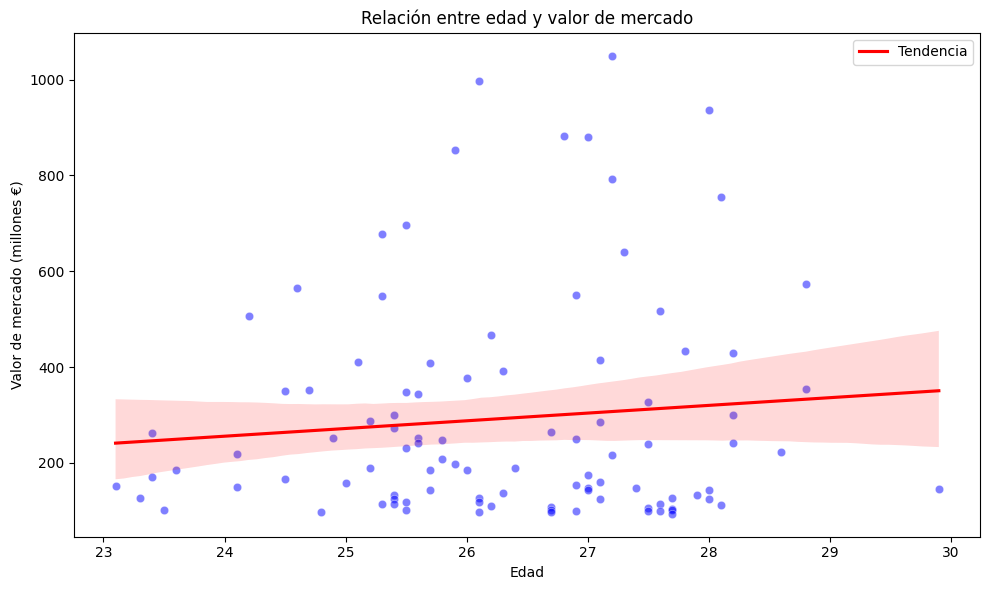

In [28]:
# ¿Existe relación entre edad y valor económico?
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Age", y="Market_value", alpha=0.5, color="blue")

# Línea de tendencia
sns.regplot(data=df, x="Age", y="Market_value", scatter=False, color="red", label="Tendencia")

# Correlación numérica
correlacion = df["Age"].corr(df["Market_value"])
print(f"Correlación entre edad y valor de mercado: {correlacion:.2f}")

plt.title("Relación entre edad y valor de mercado")
plt.xlabel("Edad")
plt.ylabel("Valor de mercado (millones €)")
plt.legend()
plt.tight_layout()
plt.show()

## ¿Existe relación entre edad y valor económico?
La correlación indica que existe una relación negativa entre edad y
valor de mercado — los jugadores más jóvenes tienden a tener mayor
valor económico, lo que refleja el potencial de desarrollo como
factor clave en la valoración.

Competition
Liga Profesional      27.700000
Premiership           27.500000
LaLiga                27.292857
Série A               27.100000
Serie A               26.956250
Championship          26.800000
Premier League        26.740000
Süper Lig             26.600000
Liga Bwin             26.300000
1.HNL                 26.200000
Super League 1        26.100000
Premier Liga          26.100000
Bundesliga            25.078571
Eredivisie            24.700000
Ligue 1               24.657143
Jupiler Pro League    23.700000
Name: Age, dtype: float64


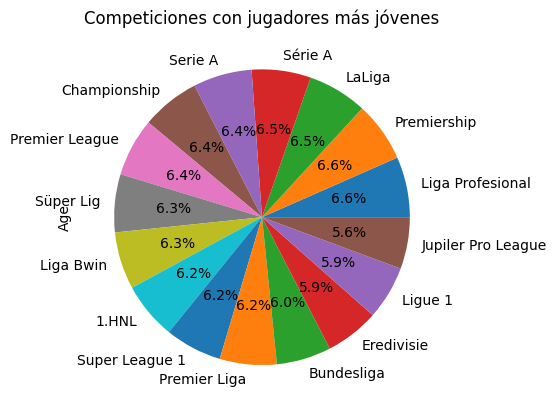

In [34]:
# ¿Qué competiciones tienen jugadores más jóvenes?

competicionesmasjovenes = df.groupby("Competition")["Age"].mean().sort_values(ascending=False)
print(competicionesmasjovenes)

competicionesmasjovenes.plot(kind = "pie", autopct="%1.1f%%")
plt.title("Competiciones con jugadores más jóvenes")
plt.show()

## ¿Qué competiciones tienen jugadores más jóvenes?
Las ligas con jugadores más jóvenes en promedio suelen ser competiciones
de menor nivel económico, donde los clubes apuestan por el desarrollo
de talento joven en lugar de fichajes consolidados.

# Conclusiones Generales

- Las ligas Top 5 europeas (Premier League, LaLiga, Ligue 1, Serie A, Bundesliga)
  dominan el mercado futbolístico tanto en valor promedio como en equipos más valiosos.
- La edad de mayor valor de mercado se concentra entre los 24-27 años.
- Existe una relación negativa entre edad y valor económico — el talento joven
  es el activo más valioso en el fútbol moderno.
- La Premier League concentra el mayor poder económico a nivel global.